# 2. Feature Engineering

This notebook prepares the NASA Turbofan Engine dataset for modeling.

The goal of this stage is to transform raw sensor measurements into more informative features that better capture engine degradation over time.

The feature engineering process includes:

- selecting informative sensors identified during EDA
- clipping Remaining Useful Life (RUL)
- creating rolling statistics
- creating trend-based features
- preparing the final dataset for modeling

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2.1 Load Data

The dataset used here is the output from the EDA stage, including the computed Remaining Useful Life (RUL) target.

This notebook assumes that the training data has already been cleaned and that the RUL column has been created.

In [10]:
df_train = pd.read_csv("/Users/junghanlee/Downloads/1. Python Code/2. NASA Turbofan Jet Engine/1. Data/processed/train_after_eda.csv")
df_train.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191.0
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190.0
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189.0
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188.0
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187.0


In [11]:
print(df_train.shape)
print(df_train.columns.tolist())

(20631, 27)
['engine_id', 'cycle', 'setting_1', 'setting_2', 'setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'RUL']


### 2.2 RUL Clipping

In the early life of an engine, sensor values often remain relatively stable even though the raw RUL may still be very large.

To reduce noise in the target and focus the model on the actual degradation phase, the RUL target is clipped at an upper threshold.

This is a common approach in predictive maintenance literature.

In [12]:
df_train["RUL_raw"] = df_train["RUL"]
df_train["RUL"] = df_train["RUL"].clip(upper=125)

df_train[["RUL_raw", "RUL"]].head()

,RUL_raw,RUL
0,191.0,125.0
1,190.0,125.0
2,189.0,125.0
3,188.0,125.0
4,187.0,125.0


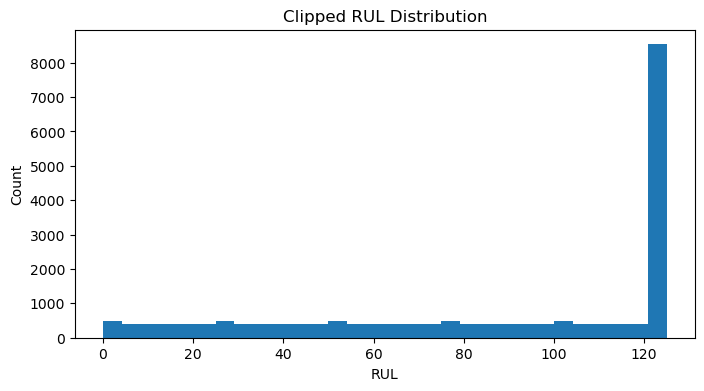

In [13]:
plt.figure(figsize=(8,4))
plt.hist(df_train["RUL"], bins=30)
plt.title("Clipped RUL Distribution")
plt.xlabel("RUL")
plt.ylabel("Count")
plt.show()

### 2.3 Sensor Selection

Based on the EDA results, only sensors with meaningful variability and useful degradation patterns were retained.

Variables such as `engine_id` and `cycle` are not used as modeling features:

- `engine_id` is only an identifier
- `cycle` is strongly tied to the target definition and may lead to leakage

The following sensors were selected as the main raw inputs for feature engineering.

In [14]:
selected_sensors = [
    "sensor_2", "sensor_3", "sensor_4", "sensor_7", "sensor_8",
    "sensor_9", "sensor_11", "sensor_12", "sensor_13",
    "sensor_14", "sensor_15", "sensor_20", "sensor_21"
]

selected_sensors

['sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_7',
 'sensor_8',
 'sensor_9',
 'sensor_11',
 'sensor_12',
 'sensor_13',
 'sensor_14',
 'sensor_15',
 'sensor_20',
 'sensor_21']

In [15]:
base_columns = ["engine_id", "cycle", "RUL"]
df_fe = df_train[base_columns + selected_sensors].copy()

df_fe.head()

,engine_id,cycle,RUL,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_20,sensor_21
0,1,1,125.0,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,39.06,23.4190
1,1,2,125.0,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,39.00,23.4236
2,1,3,125.0,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,38.95,23.3442
3,1,4,125.0,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,38.88,23.3739
4,1,5,125.0,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,38.90,23.4044


### 2.4 Rolling Statistics

Engine degradation is not captured only by raw sensor values. The change in sensor behavior over recent cycles is also important.

To capture these temporal patterns, rolling statistics are created for each selected sensor:

- rolling mean: smooths short-term noise and captures local trend
- rolling standard deviation: captures instability and fluctuation

These features help the model understand not only current sensor levels, but also recent behavior over time.

In [16]:
window = 5

for sensor in selected_sensors:
    df_fe[f"{sensor}_roll_mean"] = (
        df_fe.groupby("engine_id")[sensor]
        .rolling(window)
        .mean()
        .reset_index(level=0, drop=True)
    )

    df_fe[f"{sensor}_roll_std"] = (
        df_fe.groupby("engine_id")[sensor]
        .rolling(window)
        .std()
        .reset_index(level=0, drop=True)
    )

### 2.5 Trend Features

To capture the direction of degradation, first-order difference features are created.

These features measure how much each sensor changes from one cycle to the next.

This helps distinguish between:

- stable sensor behavior
- gradual degradation
- rapid deterioration

In [18]:
for sensor in selected_sensors:
    df_fe[f"{sensor}_diff"] = df_fe.groupby("engine_id")[sensor].diff()

### 2.6 Optional Lag Features

Lag features preserve the sensor value from previous cycles and can help the model detect short-term temporal structure.

For the baseline version of this project, rolling statistics and first differences may already be sufficient. Lag features can be added later if needed.

In [19]:
for sensor in selected_sensors:
    df_fe[f"{sensor}_lag1"] = df_fe.groupby("engine_id")[sensor].shift(1)

### 2.7 Handling Missing Values

Rolling statistics, differences, and lag features introduce missing values at the beginning of each engine sequence.

These rows are removed because they do not contain complete temporal information.

In [20]:
print("Before dropping NaNs:", df_fe.shape)

df_fe = df_fe.dropna().reset_index(drop=True)

print("After dropping NaNs:", df_fe.shape)

Before dropping NaNs: (20631, 68)
After dropping NaNs: (20231, 68)


### 2.10 Final Feature Set

The final modeling dataset includes:

- raw selected sensor values
- rolling mean features
- rolling standard deviation features
- first-difference trend features
- optional lag features if included

This produces a richer representation of engine condition than raw sensor values alone.

In [21]:
print("Total number of columns:", len(df_fe.columns))
df_fe.head()

Total number of columns: 68


,engine_id,cycle,RUL,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,...,sensor_7_lag1,sensor_8_lag1,sensor_9_lag1,sensor_11_lag1,sensor_12_lag1,sensor_13_lag1,sensor_14_lag1,sensor_15_lag1,sensor_20_lag1,sensor_21_lag1
0,1,5,125.0,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,...,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,38.88,23.3739
1,1,6,125.0,642.10,1584.47,1398.37,554.67,2388.02,9049.68,47.16,...,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,38.90,23.4044
2,1,7,125.0,642.48,1592.32,1397.77,554.34,2388.02,9059.13,47.36,...,554.67,2388.02,9049.68,47.16,521.68,2388.03,8132.85,8.4108,38.98,23.3669
3,1,8,125.0,642.56,1582.96,1400.97,553.85,2388.00,9040.80,47.24,...,554.34,2388.02,9059.13,47.36,522.32,2388.03,8132.32,8.3974,39.10,23.3774
4,1,9,125.0,642.12,1590.98,1394.80,553.69,2388.05,9046.46,47.29,...,553.85,2388.00,9040.80,47.24,522.47,2388.03,8131.07,8.4076,38.97,23.3106


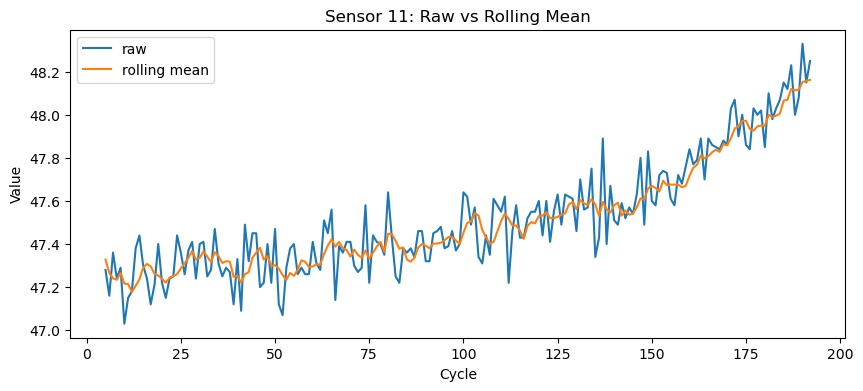

In [22]:
engine_1 = df_fe[df_fe["engine_id"] == 1]

plt.figure(figsize=(10,4))
plt.plot(engine_1["cycle"], engine_1["sensor_11"], label="raw")
plt.plot(engine_1["cycle"], engine_1["sensor_11_roll_mean"], label="rolling mean")
plt.title("Sensor 11: Raw vs Rolling Mean")
plt.xlabel("Cycle")
plt.ylabel("Value")
plt.legend()
plt.show()

In [24]:
df_fe.to_csv("/Users/junghanlee/Downloads/1. Python Code/2. NASA Turbofan Jet Engine/1. Data/processed/train_feature_engineered.csv", index=False)

### 2.11 Summary

In this notebook, the raw sensor dataset was transformed into a modeling-ready feature set.

Key steps included:

- clipping extreme RUL values
- selecting informative sensors
- generating rolling mean and rolling standard deviation features
- generating first-difference trend features
- removing incomplete rows created by temporal transformations

The resulting dataset is better suited for machine learning models that predict Remaining Useful Life.